# Análise Exploratória e Calibração das Constantes ($c_i$, $k_i$)

De acordo com o modelo teórico de tempo de processamento descrito em `modelo.md`:

$$T_i = c_i\frac{S_i}{f_i-k_i}$$

Onde:
- $S_i$ é o tamanho em bits do dataset do dispositivo $i$
- $f_i$ é a frequência de CPU do dispositivo $i$
- $c_i$ e $k_i$ são constantes empíricas dependentes das características do hardware.

Neste notebook, utilizaremos os dados de calibração (`calibrar_cn_x.csv`). Cada arquivo CSV consiste em uma execução (repetição) do experimento.
Como a frequência de operação não está disponível diretamente no CSV, extraímos a relação de que a primeira linha contém apenas o tamanho dos dados ($S_i$) e deve ser desconsiderada na contagem de execuções de treinamento. As demais linhas dentro de cada CSV correspondem a um varrimento de frequências, começando de $f_{min}$ até $f_{max}$ em intervalos iguais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import json
import os
from scipy.optimize import curve_fit

# 1. Carregar as constantes de frequência do json
with open('../sta_const.json', 'r') as f:
    sta_const = json.load(f)

N = sta_const['N']
f_min = [val * 1e9 for val in sta_const['f_min']]
f_max = [val * 1e9 for val in sta_const['f_max']]

# 2. Processar os CSVs das execuções
csv_files = glob.glob(os.path.join('data', '*.csv'))

df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    
    # Extrai S_i (tamanho do dataset) da primeira linha (index 0)
    S_vals = {}
    for i in range(N):
        col_name = f'sta{i}_datasz'
        if col_name in df.columns:
            S_vals[i] = df.loc[0, col_name]
            
    # Descarta a primeira linha e reseta o index para os dados restantes
    df = df.drop(index=0).reset_index(drop=True)
    num_steps = len(df)
    
    # Adiciona colunas de frequência para cada STA distribuída linearmente nas linhas
    for i in range(N):
        if i in S_vals:
            # As frequências variam linearmente entre f_min e f_max ao longo das linhas do csv
            df[f'freq_sta{i}'] = np.linspace(f_min[i], f_max[i], num_steps)
            df[f'sta{i}_datasz'] = S_vals[i] # Repõe o valor fixo
            
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
print(f"Foram carregadas {len(csv_files)} execuções (CSVs) com {num_steps} passos de frequência cada.")

/home/nilo/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-4n6_w4kv because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Foram carregadas 9 execuções (CSVs) com 39 passos de frequência cada.


## Análise Exploratória (Gráficos T vs f)

Para analisarmos o tempo de treinamento, vamos agrupar os dados através das diversas execuções (CSVs) considerando a mesma frequência. Com isso, obteremos a **média** e o **desvio padrão** para as barras de erro.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


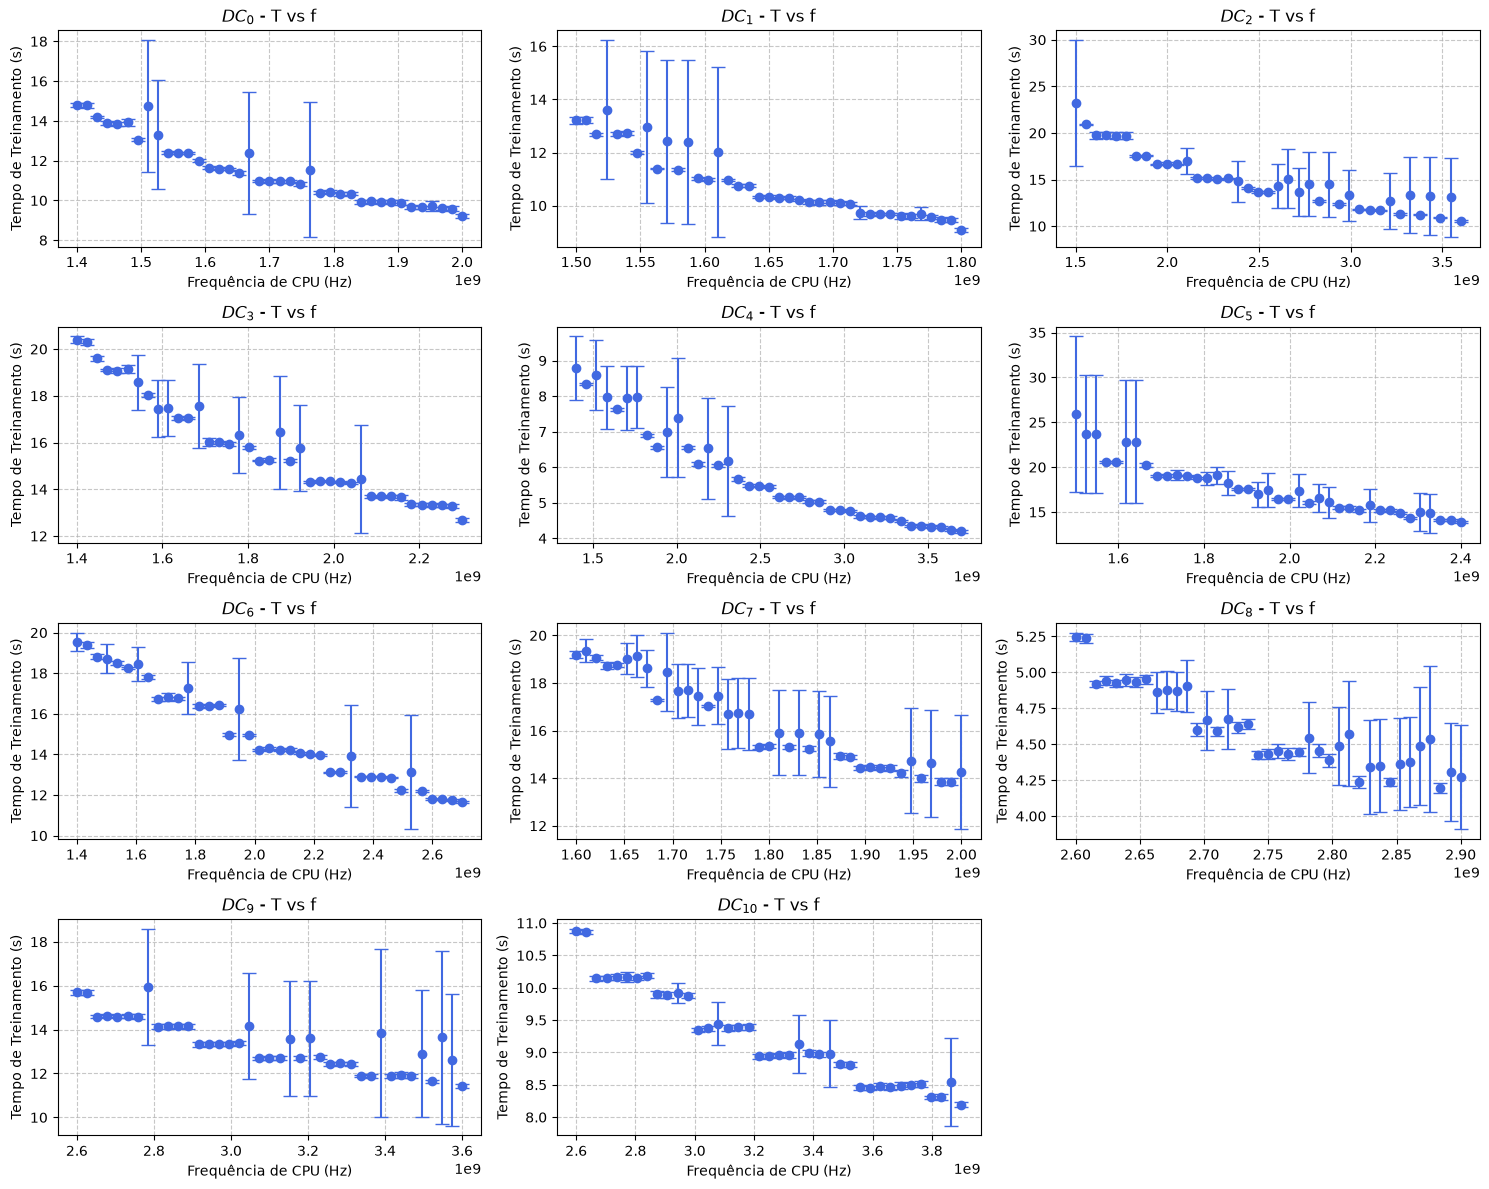

In [2]:
# Agrupamento para extrair média e desvio padrão entre as execuções
stats = []

for i in range(N):
    time_col = f'training_time_sta{i}'
    freq_col = f'freq_sta{i}'
    size_col = f'sta{i}_datasz'
    
    if time_col in df_all.columns:
        # Agrupamos pelo valor da frequência (que é idêntico em todas as repetições)
        grouped = df_all.groupby(freq_col)[time_col]
        
        mean_times = grouped.mean()
        std_times = grouped.std()
        
        freqs = mean_times.index.values
        S_i = df_all[size_col].iloc[0]
        
        stats.append({
            'STA': i,
            'freqs': freqs,
            'T_mean': mean_times.values,
            'T_std': std_times.values,
            'S': S_i
        })

# Plotando os dados experimentais
fig, axes = plt.subplots(int(np.ceil(N/3)), 3, figsize=(15, 12))
axes = axes.flatten()

for stat in stats:
    i = stat['STA']
    ax = axes[i]
    
    ax.errorbar(stat['freqs'], stat['T_mean'], yerr=stat['T_std'], 
                fmt='o', capsize=5, label=f'$DC_{{{i}}}$ (Dados)', color='royalblue')
    ax.set_title(f'$DC_{{{i}}}$ - T vs f')
    ax.set_xlabel('Frequência de CPU (Hz)')
    ax.set_ylabel('Tempo de Treinamento (s)')
    ax.grid(True, linestyle='--', alpha=0.7)

# Oculta subplots não utilizados
for j in range(len(stats), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('analise_tempo_frequencia_plot_1.eps', format='eps', bbox_inches='tight')
plt.show()

## Calibração das Constantes Teóricas

Utilizaremos `scipy.optimize.curve_fit` para encontrar $c_i$ e $k_i$. Vale lembrar que para o modelo fazer sentido fisicamente:
- $c_i > 0$
- $f_i - k_i > 0 \implies k_i < f_{min}$ matematicamente para o tempo não explodir ou se tornar negativo (mas conforme sua restrição, limitaremos $0 \le k_i < f_{max}$).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


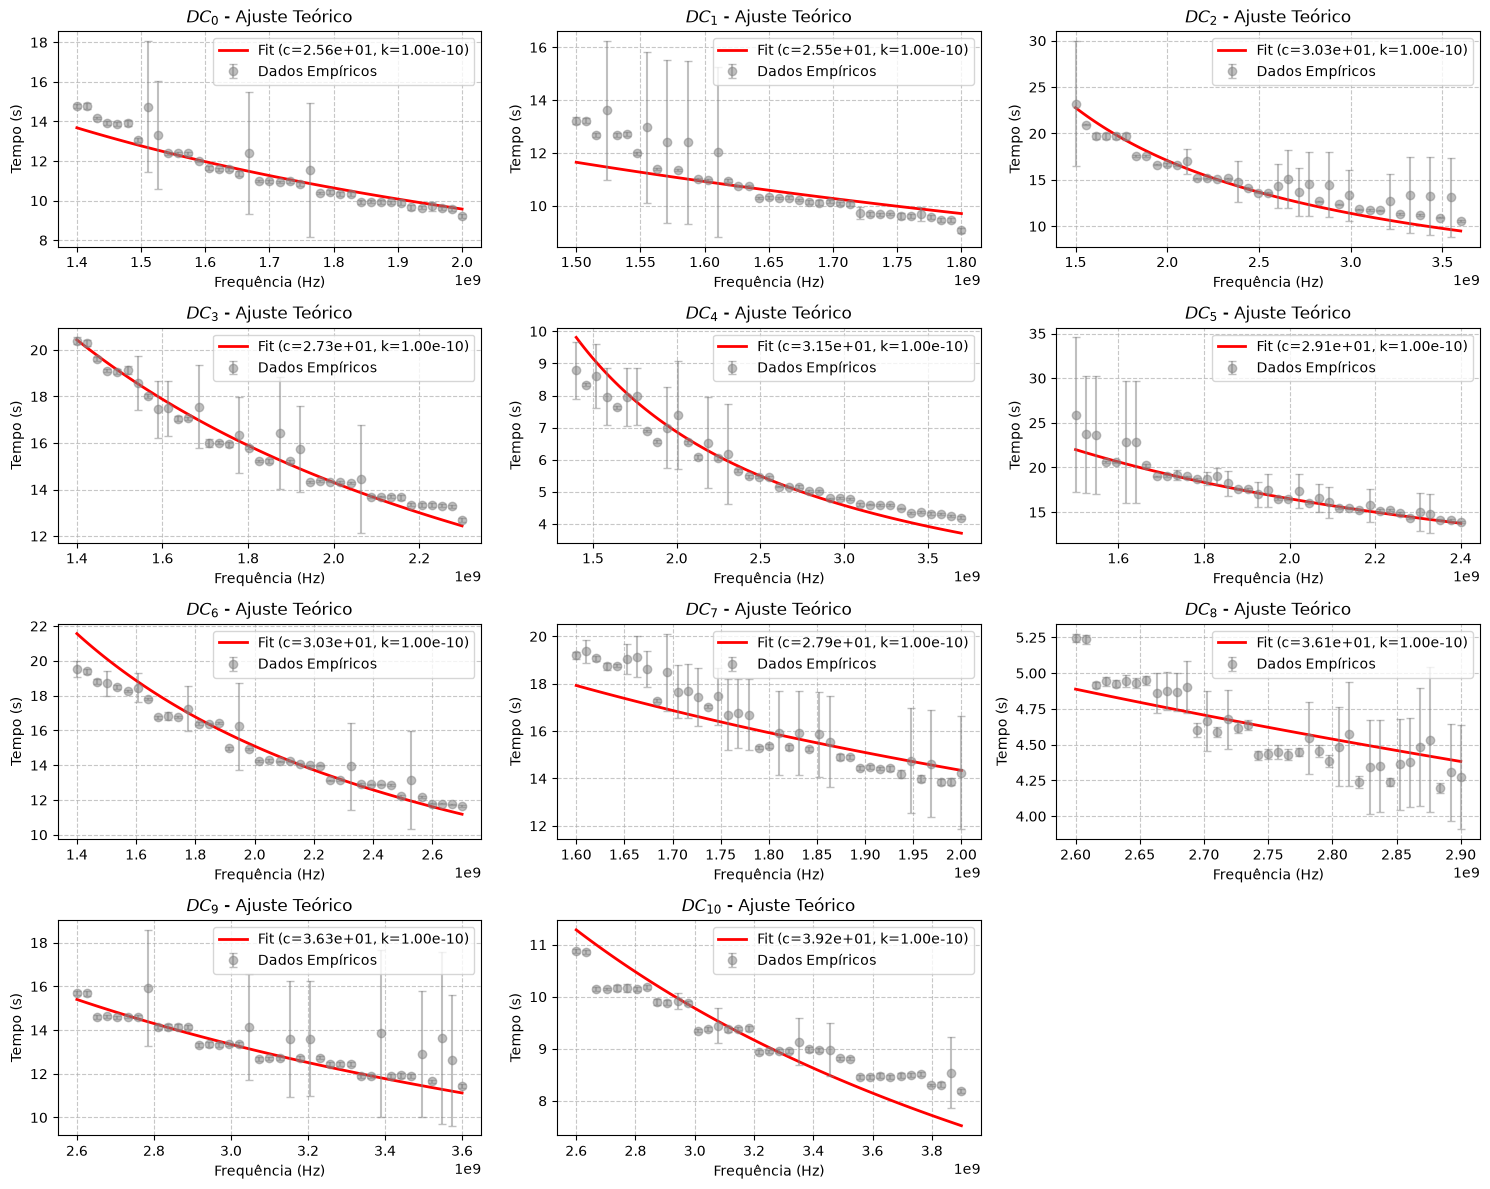

,STA,c_i,k_i
0,0,25.636260,1.000000e-10
1,1,25.533207,1.000000e-10
2,2,30.282090,1.000000e-10
3,3,27.313179,1.000000e-10
4,4,31.482889,1.000000e-10
5,5,29.074004,1.000000e-10
6,6,30.325954,1.000000e-10
7,7,27.935447,1.000000e-10
8,8,36.069661,1.000000e-10
9,9,36.321188,1.000000e-10


In [3]:
def theoretical_model(f, c, k, S):
    return c * S / (f - k)

calibrated_params = []

fig, axes = plt.subplots(int(np.ceil(N/3)), 3, figsize=(15, 12))
axes = axes.flatten()

for stat in stats:
    i = stat['STA']
    f_vals = stat['freqs']
    T_vals = stat['T_mean']
    T_std = stat['T_std']
    S_i = stat['S']
    
    # Wrapper de função fixando S_i para a regressão apenas sobre c e k
    def fit_func(f, c, k):
        return theoretical_model(f, c, k, S_i)
    
    # Chutes iniciais (p0)
    c_initial = (np.mean(T_vals) * np.mean(f_vals)) / S_i
    k_initial = 0.0
    
    # Limites (bounds): c > 0 e 0 <= k < f_max para atender à restrição (k necessariamente positivo e menor que f_max)
    bounds = ([0.0, 0.0], [np.inf, np.max(f_vals) - 1.0])
    
    ax = axes[i]
    
    try:
        # Fit não linear sobrepondo os erros
        # Se o desvio padrão tiver zeros, aplicamos um peso unitário ou ignoramos o erro nas partes exatas.
        sigma = np.where(T_std == 0, 1e-5, T_std) 
        
        popt, pcov = curve_fit(fit_func, f_vals, T_vals, 
                               p0=[c_initial, k_initial], 
                               bounds=bounds,
                               sigma=sigma,
                               absolute_sigma=False)
        c_opt, k_opt = popt
        
        # Plot da curva suavizada a partir do modelo
        f_smooth = np.linspace(np.min(f_vals), np.max(f_vals), 100)
        T_smooth = fit_func(f_smooth, c_opt, k_opt)
        
        ax.plot(f_smooth, T_smooth, 'r-', linewidth=2, label=f'Fit (c={c_opt:.2e}, k={k_opt:.2e})')
        
    except Exception as e:
        print(f"Erro na regressão para $DC_{{{i}}}$: {e}")
        c_opt, k_opt = np.nan, np.nan
        
    calibrated_params.append({
        'STA': i,
        'c_i': c_opt,
        'k_i': k_opt
    })
    
    # Plot de fundo dos dados originais para comparação visual
    ax.errorbar(f_vals, T_vals, yerr=T_std, fmt='o', capsize=3, alpha=0.5, label='Dados Empíricos', color='gray')
    
    ax.set_title(f'$DC_{{{i}}}$ - Ajuste Teórico')
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Tempo (s)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper right')

for j in range(len(stats), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('analise_tempo_frequencia_plot_2.eps', format='eps', bbox_inches='tight')
plt.show()

df_calibrated = pd.DataFrame(calibrated_params)
display(df_calibrated)

## Salvar Constantes Calibradas

Atualizando o arquivo `sta_const_calibrado.json` com os valores ajustados para `c_i` e `k_i` (formatados com 6 algarismos significativos).

In [4]:
calibrado_path = '../sta_const_calibrado.json'

with open(calibrado_path, 'r') as f:
    sta_const_calibrado = json.load(f)

# Garantir que a lista k exista
if 'k' not in sta_const_calibrado:
    sta_const_calibrado['k'] = [-1] * len(sta_const_calibrado['c'])

for idx, row in df_calibrated.iterrows():
    sta = int(row['STA'])
    if not np.isnan(row['c_i']):
        c_val = float(f"{row['c_i']:.6g}")
        k_val = float(f"{row['k_i']:.6g}")
        
        sta_const_calibrado['c'][sta] = c_val
        sta_const_calibrado['k'][sta] = k_val

with open(calibrado_path, 'w') as f:
    json.dump(sta_const_calibrado, f, indent=2)

print(f"Valores calibrados salvos com sucesso em {calibrado_path}")

Valores calibrados salvos com sucesso em ../sta_const_calibrado.json
